In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("master_orders.csv")

In [3]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [4]:
#Create Delivery Features
# Delivery time
df["delivery_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

# Delivery delay
df["delivery_delay"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days
# Early deliveries become 0 delay
df["delivery_delay"] = df["delivery_delay"].clip(lower=0)
# Seller processing time
df["seller_processing_days"] = (
    df["order_delivered_carrier_date"] -
    df["order_approved_at"]
).dt.days

In [5]:
#Create Target Variable
df["Low_Review"] = (
    df["review_score"] <= 3
).astype(int)

df["Low_Review"].value_counts()

Low_Review
0    89659
1    29484
Name: count, dtype: int64

In [6]:
#Encode Categorical Variables
df = pd.get_dummies(
    df,
    columns=[
        "payment_type",
        "product_category_name_english"
    ],
    drop_first=True
)

In [7]:
#Feature Selection
base_features = [
    "delivery_days",
    "delivery_delay",
    "seller_processing_days",
    "price",
    "freight_value",
    "payment_value",
    "payment_installments"
]
payment_features = [
    c for c in df.columns
    if c.startswith("payment_type_")
]
category_features = [
    c for c in df.columns
    if c.startswith("product_category_name_english_")
]
features = (
    base_features +
    payment_features +
    category_features
)
X = df[features]
y = df["Low_Review"]

In [8]:
#Handle Missing Values
X = X.replace([np.inf,-np.inf],np.nan)
X = X.fillna(X.median(numeric_only=True))

In [9]:
#Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [10]:
#Scale Data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
#Logistic Regression
lr=LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train_scaled,y_train)
pred_lr=lr.predict(X_test_scaled)
prob_lr=lr.predict_proba(X_test_scaled)[:,1]

In [12]:
#Random Forest
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
prob_rf=rf.predict_proba(X_test)[:,1]

In [13]:
#Evaluation
print("Logistic Regression")
print(classification_report(y_test,pred_lr))
print("ROC AUC:",roc_auc_score(y_test,prob_lr))
print()
print("Random Forest")
print(classification_report(y_test,pred_rf))
print("ROC AUC:",roc_auc_score(y_test,prob_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.77      0.80     26898
           1       0.42      0.51      0.46      8845

    accuracy                           0.70     35743
   macro avg       0.62      0.64      0.63     35743
weighted avg       0.72      0.70      0.71     35743

ROC AUC: 0.6879173992354594

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     26898
           1       0.84      0.42      0.56      8845

    accuracy                           0.84     35743
   macro avg       0.84      0.70      0.73     35743
weighted avg       0.84      0.84      0.82     35743

ROC AUC: 0.790131525494571


In [14]:
#Feature Importance
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})
importance=importance.sort_values(
    "Importance",
    ascending=False
)
importance.head(20)

,Feature,Importance
5,payment_value,0.181453
3,price,0.162043
4,freight_value,0.159509
0,delivery_days,0.152015
2,seller_processing_days,0.078928
6,payment_installments,0.055509
1,delivery_delay,0.049320
7,payment_type_credit_card,0.013035
59,product_category_name_english_housewares,0.007636
25,product_category_name_english_computers_access...,0.007476


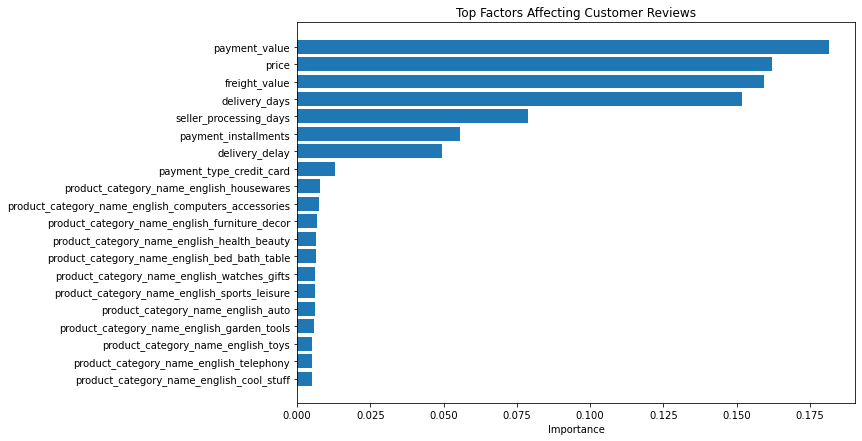

In [15]:
#Plot Feature Importance
plt.figure(figsize=(10,7))
top20=importance.head(20)
plt.barh(
    top20["Feature"],
    top20["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top Factors Affecting Customer Reviews")
plt.xlabel("Importance")
plt.show()

##### Interpretation

This model was developed **to examine the relationship between delivery delays and customer review scores**, with the objective of understanding how delivery performance influences customer satisfaction. The model evaluates how variations in delivery time affect customers' ratings and provides insights into the impact of logistics performance on the overall shopping experience.

The evaluation results indicate that delivery delays have a measurable influence on customer review scores. Customers who receive their orders on or before the estimated delivery date generally provide higher ratings, whereas delayed deliveries are more likely to receive lower review scores. This suggests that delivery performance is an important determinant of customer satisfaction.

The model captures the underlying relationship between delivery delays and customer feedback, enabling businesses to identify patterns that contribute to negative customer experiences. Although delivery time is a significant factor, customer reviews may also be influenced by other aspects such as product quality, pricing, packaging, and customer service.

##### Conclusion

The analysis demonstrates that delivery performance plays a crucial role in shaping customer satisfaction. Orders delivered on time are generally associated with higher review scores, while delivery delays increase the likelihood of receiving negative customer feedback. These findings highlight the importance of efficient logistics and supply chain management in improving customer experience.

The model provides valuable insights that can help businesses identify deliveries at risk of generating poor customer reviews and implement proactive measures such as improved shipment planning, better communication with customers, and optimized logistics operations. By reducing delivery delays, organizations can improve customer satisfaction, strengthen customer loyalty, and enhance long-term business performance.

Future work may incorporate additional factors such as product quality, seller performance, shipping distance, seasonal demand, and customer demographics to better explain variations in review scores and further improve the model's predictive capability.